This notebook constructs the final feature sets (A, B, C, D, E1, E2) from `05_absa_bert_scores.csv`.

| Set | Core Features | NaN in Core |
|---|---|---|
| A | Numerical sub-ratings | Yes → imputed in modelling pipeline |
| B | VADER document-level scores | None |
| C | Rule-based aspect VADER scores | Yes → not mentioned or insufficient tokens to compute a score; retained as NaN |
| D | B + C | Yes → aspect columns only; retained as NaN |
| E1 | ABSA-BERT full inference scores | None |
| E2 | ABSA-BERT keyword-gated scores | Yes → not mentioned; retained as NaN |


In `01_eda_cleaning.ipynb`, all 0 values were replaced with None, since the rating scale is 1–5 and 0 is not a valid observed value. This applies uniformly regardless of whether the field is required - a missing value is treated the same whether it stems from a skipped question or a genuinely absent aspect.


**Scope of This Notebook**

- Review imputation strategy for Set A (actual imputation is deferred to the modelling pipeline to prevent data leakage)
- Construct missing-value indicators for Set A, Set C, and Set E2
- Select final columns per set
- Save each set as a separate CSV

**Common Features for All Sets**
- `Verified`, `Type Of Traveller`, `Seat Type`, `Covid_Period`, `review_length`

## **1. Data Load**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv('../1_data/processed/05_absa_bert_scores.csv')
print(f"Loaded: {df.shape}")
df.info()

Loaded: (22980, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22980 entries, 0 to 22979
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Airline Name            22980 non-null  object 
 1   Verified                22980 non-null  bool   
 2   Type Of Traveller       22980 non-null  object 
 3   Seat Type               22980 non-null  object 
 4   Seat Comfort            18763 non-null  float64
 5   Cabin Staff Service     18673 non-null  float64
 6   Food & Beverages        14162 non-null  float64
 7   Ground Service          18292 non-null  float64
 8   Inflight Entertainment  10245 non-null  float64
 9   Wifi & Connectivity     5896 non-null   float64
 10  Value For Money         21806 non-null  float64
 11  Recommended             22980 non-null  int64  
 12  Covid_Period            22980 non-null  int64  
 13  review_length           22980 non-null  int64  
 14  Full_Review       

## **2. Set A Imputation**

In [ ]:
# 2.1 Missing Value Check

rating_cols = [
    'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages',
    'Ground Service', 'Inflight Entertainment', 'Wifi & Connectivity',
    'Value For Money'
]

print(df[rating_cols].isnull().sum().to_frame('missing_count').assign(
    missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(1)
))

                        missing_count  missing_pct
Seat Comfort                     4217         18.4
Cabin Staff Service              4307         18.7
Food & Beverages                 8818         38.4
Ground Service                   4688         20.4
Inflight Entertainment          12735         55.4
Wifi & Connectivity             17084         74.3
Value For Money                  1174          5.1


> ### **Drop 'Inflight Entertainment' and 'Wifi & Connectivity'**
> `Inflight Entertainment` and `Wifi & Connectivity` will be excluded due to high missingness. `Food & Beverages` has fairly large missing values, but this needs to be investigated further to confirm whether imputation is acceptable or not.

In [ ]:
# 2.2 Missing & Distribution Check

set_a_rating_cols = [
    'Seat Comfort',
    'Cabin Staff Service',
    'Food & Beverages',
    'Ground Service',
    'Value For Money'
]

print("=== Missing & Distribution Summary ===")
for col in set_a_rating_cols:
    missing_pct = df[col].isna().mean() * 100
    print(f"  {col:<25} missing: {missing_pct:.1f}%  median: {df[col].median()}  mean: {df[col].mean():.3f}")

=== Missing & Distribution Summary ===
  Seat Comfort              missing: 18.4%  median: 3.0  mean: 2.635
  Cabin Staff Service       missing: 18.7%  median: 3.0  mean: 2.886
  Food & Beverages          missing: 38.4%  median: 2.0  mean: 2.595
  Ground Service            missing: 20.4%  median: 1.0  mean: 2.349
  Value For Money           missing: 5.1%  median: 2.0  mean: 2.459


In [35]:
# 2.3 Overall vs Group (Traveller, Seat Type) Median Comparison

group_cols = ['Type Of Traveller', 'Seat Type']

for group in group_cols:
    print(f"\n=== Median by {group} (with Overall) ===")
    
    group_median = df.groupby(group)[set_a_rating_cols].median().round(2)
    overall_median = df[set_a_rating_cols].median().round(2)
    overall_median.name = 'Overall'
    
    combined = pd.concat([group_median, overall_median.to_frame().T])
    print(combined)


=== Median by Type Of Traveller (with Overall) ===
                Seat Comfort  Cabin Staff Service  Food & Beverages  \
Business                 3.0                  3.0               2.0   
Couple Leisure           2.0                  3.0               2.0   
Family Leisure           2.0                  2.0               2.0   
Solo Leisure             3.0                  3.0               3.0   
Unknown                  3.5                  4.0               3.0   
Overall                  3.0                  3.0               2.0   

                Ground Service  Value For Money  
Business                   2.0              2.0  
Couple Leisure             1.0              1.0  
Family Leisure             1.0              1.0  
Solo Leisure               2.0              2.0  
Unknown                    1.0              4.0  
Overall                    1.0              2.0  

=== Median by Seat Type (with Overall) ===
                 Seat Comfort  Cabin Staff Service  Food

# 2.4 Before vs After Median Imputation: Mean diff and Std change

print("=== Before vs After Imputation ===\n")
print(f"{'Column':<25} {'Missing%':>9} {'Median':>7} {'Mean(orig)':>11} {'Mean(imp)':>10} {'MeanDiff':>9} {'Std(orig)':>10} {'Std(imp)':>9}")
print("-" * 100)

for col in set_a_rating_cols:
    original = df[col].dropna()
    imputed  = df[col].fillna(df[col].median())
    missing_pct = df[col].isna().mean() * 100
    print(f"{col:<25} {missing_pct:>8.1f}% {df[col].median():>7.1f} "
          f"{original.mean():>11.3f} {imputed.mean():>10.3f} "
          f"{abs(original.mean()-imputed.mean()):>9.3f} "
          f"{original.std():>10.3f} {imputed.std():>9.3f}")

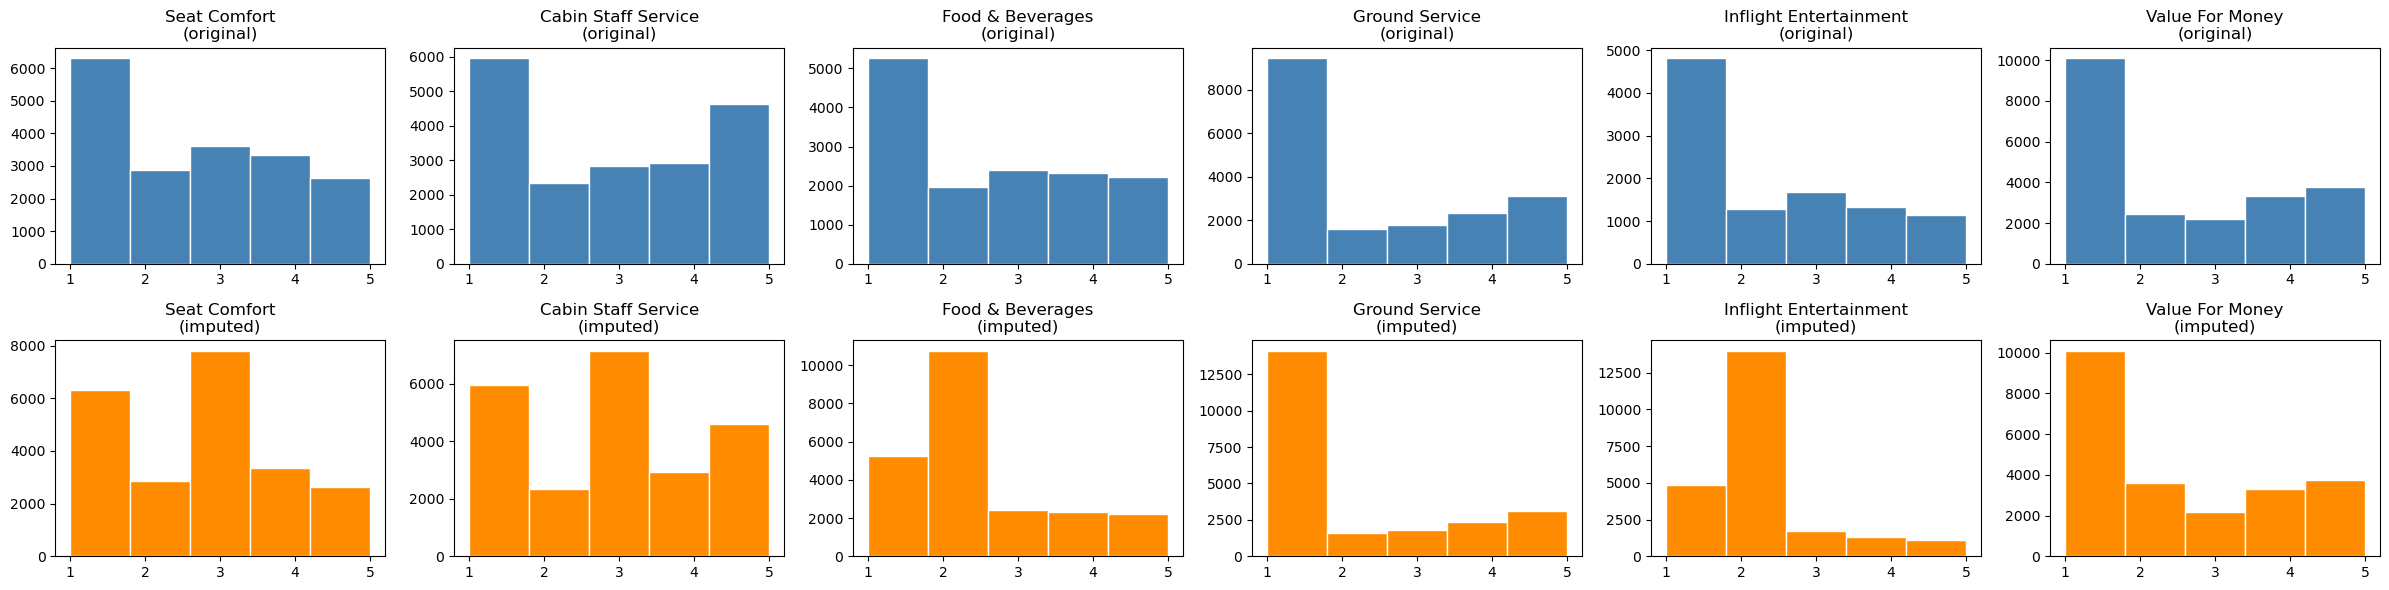

In [ ]:
import matplotlib.pyplot as plt

cols = ['Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 
        'Ground Service', 'Inflight Entertainment', 'Value For Money']

fig, axes = plt.subplots(2, len(cols), figsize=(4*len(cols), 6))

for j, col in enumerate(cols):
    axes[0, j].hist(df[col].dropna(), bins=5, color='steelblue', edgecolor='white')
    axes[0, j].set_title(f'{col}\n(original)')
    
    imputed = df[col].fillna(df[col].median())
    axes[1, j].hist(imputed, bins=5, color='darkorange', edgecolor='white')
    axes[1, j].set_title(f'{col}\n(imputed)')

plt.tight_layout()
plt.show()

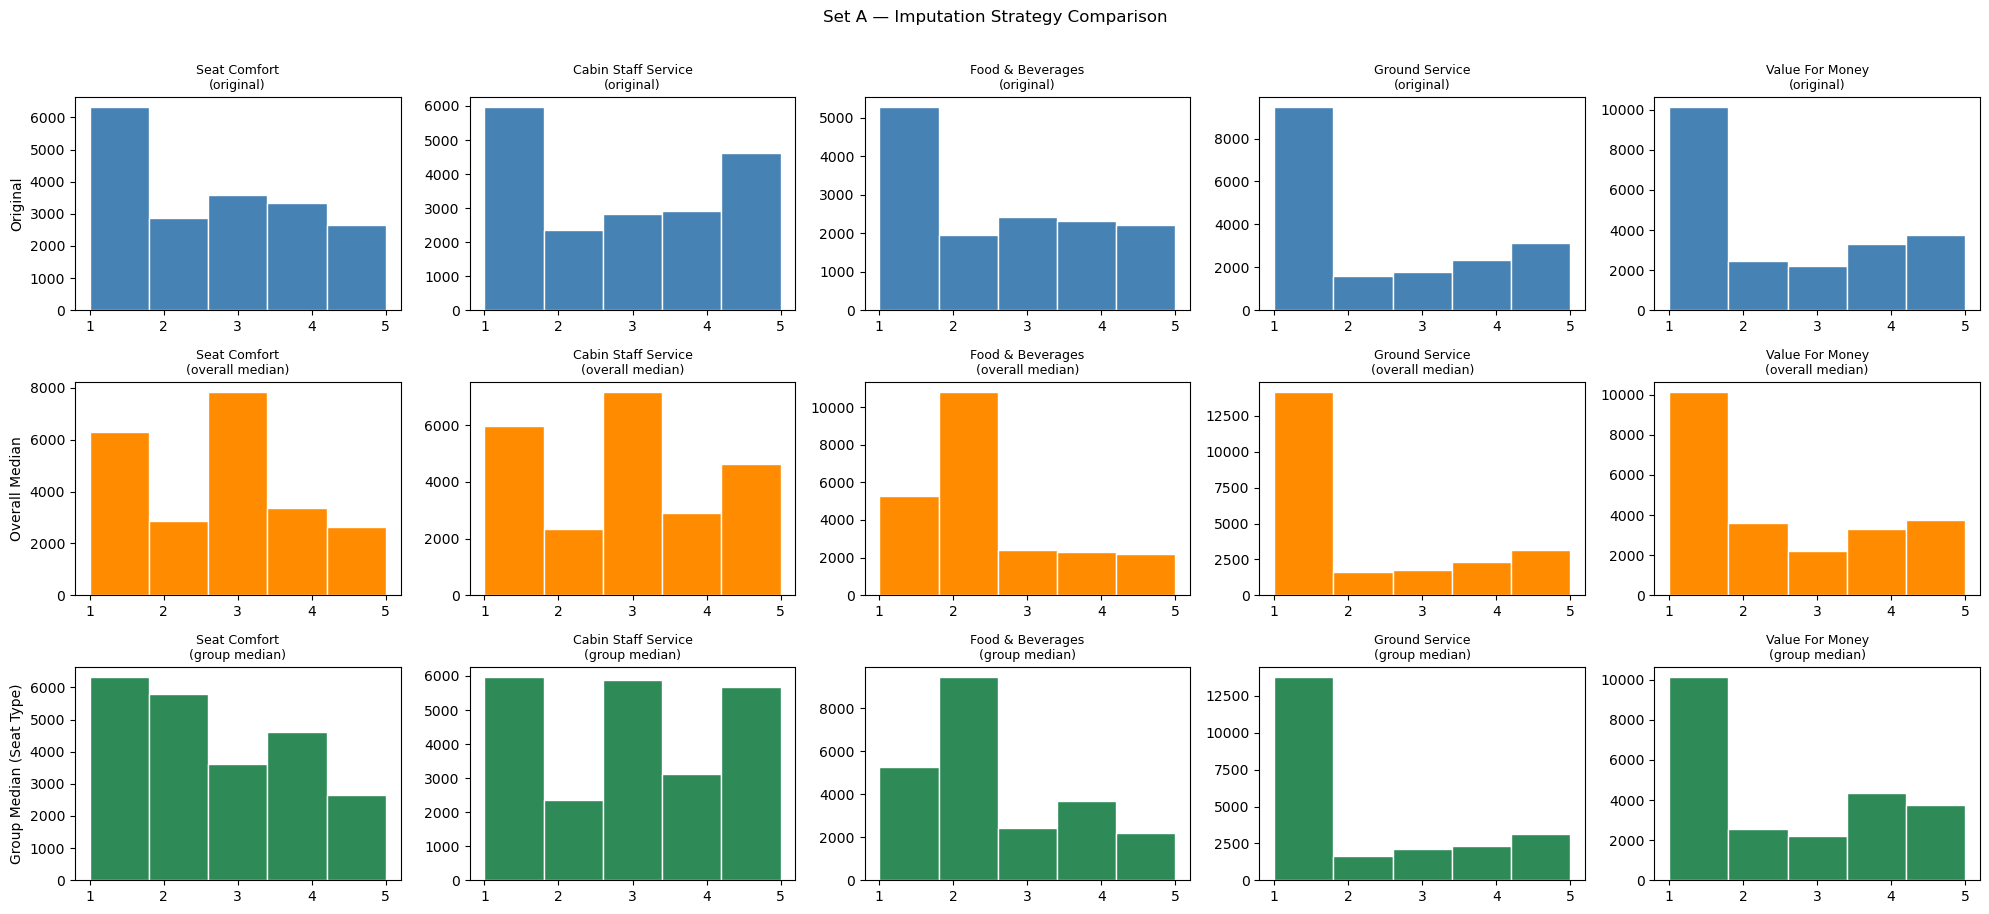

In [34]:
# 2.3 Distribution: original vs overall median imputed vs group median imputed
fig, axes = plt.subplots(3, len(set_a_rating_cols), figsize=(20, 9))

for j, col in enumerate(set_a_rating_cols):
    overall_median = df[col].median()
    group_median   = df.groupby('Seat Type')[col].transform('median')

    overall_imputed = df[col].fillna(overall_median)
    group_imputed   = df[col].fillna(group_median)

    # Original
    axes[0, j].hist(df[col].dropna(), bins=5, color='steelblue', edgecolor='white')
    axes[0, j].set_title(f'{col}\n(original)', fontsize=9)

    # Overall median imputed
    axes[1, j].hist(overall_imputed, bins=5, color='darkorange', edgecolor='white')
    axes[1, j].set_title(f'{col}\n(overall median)', fontsize=9)

    # Group median imputed
    axes[2, j].hist(group_imputed, bins=5, color='seagreen', edgecolor='white')
    axes[2, j].set_title(f'{col}\n(group median)', fontsize=9)

axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Overall Median')
axes[2, 0].set_ylabel('Group Median (Seat Type)')

plt.suptitle('Set A — Imputation Strategy Comparison', y=1.01)
plt.tight_layout()
plt.show()